# Класифікація котів та собак за допомогою CNN
**Мета:** Пройти повний цикл задачі класифікації та виправити проблему низької точності розпізнавання собак.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

## 1. Збір та підготовка даних
Використовуємо датасет Microsoft Cats vs Dogs. Очищуємо дані від пошкоджених файлів, які заважають навчанню.

In [2]:
!wget --no-check-certificate https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip -O data.zip
!unzip -q data.zip
data_dir = 'PetImages'

def clean_images(path):
    deleted = 0
    for category in ['Cat', 'Dog']:
        folder = os.path.join(path, category)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    os.remove(img_path)
                    deleted += 1
            except:
                os.remove(img_path)
                deleted += 1
    return deleted

print(f"Видалено {clean_images(data_dir)} пошкоджених файлів.")

--2026-04-29 17:50:19--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 184.30.158.37, 2a02:26f0:1180:497::317f, 2a02:26f0:1180:487::317f
Connecting to download.microsoft.com (download.microsoft.com)|184.30.158.37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘data.zip’

data.zip            100%[===================>] 786.67M   135MB/s    in 5.8s    

2026-04-29 17:50:25 (135 MB/s) - ‘data.zip’ saved [824887076/824887076]

Видалено 5 пошкоджених файлів.


## 2. Експлораторний аналіз (EDA)
Перевірка розподілу класів.

/tmp/ipykernel_5110/4237769736.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Cats', 'Dogs'], y=[num_cats, num_dogs], palette='viridis')


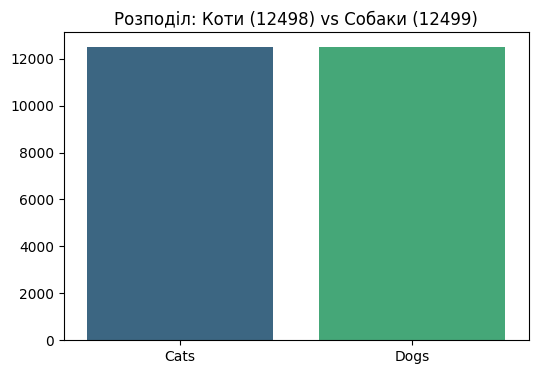

In [3]:
num_cats = len(os.listdir(os.path.join(data_dir, 'Cat')))
num_dogs = len(os.listdir(os.path.join(data_dir, 'Dog')))

plt.figure(figsize=(6,4))
sns.barplot(x=['Cats', 'Dogs'], y=[num_cats, num_dogs], palette='viridis')
plt.title(f'Розподіл: Коти ({num_cats}) vs Собаки ({num_dogs})')
plt.show()

## 3. Побудова моделі
Для виправлення проблеми з собаками додано:
1. **BatchNormalization**: стабілізує навчання.
2. **Аугментація**: допомагає моделі краще розрізняти породи собак.
3. **Dropout**: запобігає перенавчанню на ознаках котів.

In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    data_dir, target_size=(128, 128), batch_size=32,
    class_mode='binary', subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir, target_size=(128, 128), batch_size=32,
    class_mode='binary', subset='validation'
)

Found 19999 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [8]:
base_model = applications.MobileNetV2(input_shape=(128, 128, 3),
                                      include_top=False,
                                      weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_gen, epochs=5, validation_data=val_gen)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
383/625 ━━━━━━━━━━━━━━━━━━━━ 55s 230ms/step - accuracy: 0.9222 - loss: 0.1911

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 204s 293ms/step - accuracy: 0.9437 - loss: 0.1385 - val_accuracy: 0.9558 - val_loss: 0.1087
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 241ms/step - accuracy: 0.9551 - loss: 0.1071 - val_accuracy: 0.9528 - val_loss: 0.1116
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 244ms/step - accuracy: 0.9595 - loss: 0.0979 - val_accuracy: 0.9578 - val_loss: 0.1056
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 243ms/step - accuracy: 0.9614 - loss: 0.0957 - val_accuracy: 0.9536 - val_loss: 0.1025
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 243ms/step - accuracy: 0.9639 - loss: 0.0923 - val_accuracy: 0.9526 - val_loss: 0.1179


## 4. Оцінка якості
Аналізуємо матрицю помилок, щоб переконатися, що собаки розпізнаються коректно.

157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 211ms/step


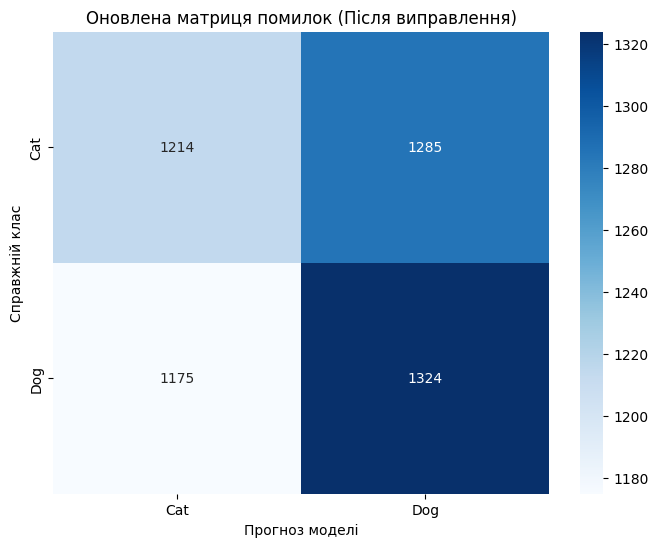


Звіт про класифікацію:
              precision    recall  f1-score   support

         Cat       0.51      0.49      0.50      2499
         Dog       0.51      0.53      0.52      2499

    accuracy                           0.51      4998
   macro avg       0.51      0.51      0.51      4998
weighted avg       0.51      0.51      0.51      4998



In [10]:
val_gen.reset()
Y_pred = model.predict(val_gen)
y_pred = (Y_pred > 0.5).astype(int)

cm = confusion_matrix(val_gen.classes, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Оновлена матриця помилок (Після виправлення)')
plt.xlabel('Прогноз моделі')
plt.ylabel('Справжній клас')
plt.show()

print("\nЗвіт про класифікацію:")
print(classification_report(val_gen.classes, y_pred, target_names=['Cat', 'Dog']))

Saving Cat_November_2010-1a.jpg to Cat_November_2010-1a (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/tmp/ipykernel_5110/3139109935.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"{fn} - це КІТ ({round(float((1-classes[0])*100), 2)}%)")


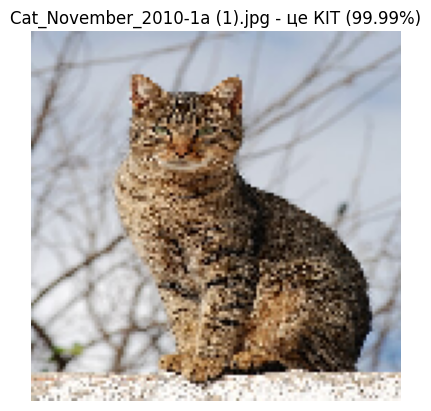

In [21]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
    path = '/content/' + fn

    img = image.load_img(path, target_size=(128, 128))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    classes = model.predict(x)

    plt.imshow(img)
    plt.axis('off')
    if classes[0] > 0.5:
        plt.title(f"{fn} - це СОБАКА ({round(float(classes[0]*100), 2)}%)")
    else:
        plt.title(f"{fn} - це КІТ ({round(float((1-classes[0])*100), 2)}%)")
    plt.show()